# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [1]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import random
import joblib
from sklearn.model_selection import StratifiedGroupKFold
import matplotlib.pyplot as plt
import time, torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from torch import amp
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import cv2
import albumentations as A

import sys
sys.path.append("../utils")
from utils import (create_balanced_split, 
                   ISIC_Multimodal_Dataset, 
                   get_best_metadata, 
                   MetadataProcessor,
                   AdvancedHairAugmentation, 
                   Microscope,
                   get_fold_datalodaers,
                   TrainableModule, 
                   remove_last_layer,   
                   plot_confusion_matrix,   
                   plot_stats)

# configure all:
class config:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_dir = Path("../data")
    models_dir = Path("../models")
    utils_dir = Path("../utils")
    submission_dir = Path("../submission")
    train_meta_csv = data_dir / "train-metadata.csv"
    test_meta_csv = data_dir / "test-metadata.csv"
    train_hdf5 = data_dir / "train-image.hdf5"
    test_hdf5 = data_dir / "test-image.hdf5"
    meta_procesor = utils_dir / "metadata_processor.pkl"
    metamodel_path = utils_dir / "metamodel.plk"
    hairs_path = utils_dir / "hairs"
    lr = 1e5
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225],
    seed = 42
    image_size = 224
    epochs = 50
    batch_size = 16
    num_imgs_epoch = 3000
    target_epoch_proportion = 0.50
    BCE_loss_pos_weight = 1
    ratio_neg_pos = 25
    val_split = 0.2             # of train
    num_folds = 5
    num_feat = 0                # 0 = use all
    fine_tuning_batch = 10      # batch to train ensemble models
    val_freq = 5                # frequency of validation analisis
    attention_dim = 256         # dimension of trained attention ensemble
    unfreeze_schedule = [
        (5, 0.2),   # in epoch 5, 20%
        (40, 0.5),  # in epoch 30, 50%
        # (65, 0.75), # in epoch 65, 75%
    ]

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(config.seed)

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and analyze the data

Because of the extreme class imbalance in the ISIC dataset (≈0.01% malignant vs. 99.99% benign), we apply two complementary strategies.  
First, we limit the number of benign samples by enforcing a controlled ratio of **25 benign lesions per malignant lesion** during training.  
Second, we apply an extensive yet medically appropriate **augmentation pipeline** to increase the effective diversity of malignant samples and reduce overfitting.

Below is a summary of the augmentation strategy used.

---

## Data Augmentation for Skin Lesion Classification (ISIC)

To improve the robustness of our multimodal classifier, we apply a set of **recommended and dermatology-consistent augmentations**, inspired by prior work on dermoscopic augmentation. In particular, our use of `AdvancedHairAugmentation` and `Microscope` artifacts was borrowed from the approach of GreatGameDota/SIIM-ISIC-Melanoma-Classification. :contentReference[oaicite:2]{index=2}

These transformations simulate realistic sources of variability such as camera angle, zoom, lighting, dermoscopic artifacts, and partial occlusions.

### 🔧 Summary of the Training Augmentation Pipeline

1. **Geometric Transformations (OneOf: ShiftScaleRotate / Affine / Perspective)**  
   A single transformation is chosen at random:
   - **ShiftScaleRotate**: small shifts, scaling (±15%), and rotations (±80°).  
   - **Affine (shear)**: simulates slight camera tilt.  
   - **Perspective**: mimics viewpoint variation.  
   **Purpose:** models acquisition differences across dermatoscopes while preserving lesion morphology.

2. **Horizontal & Vertical Flip (p=0.5 each)**  
   **Purpose:** lesions have no fixed orientation; flipping increases spatial variability safely.

3. **Resize to fixed resolution**  
   Ensures all images match the model input size.

4. **AdvancedHairAugmentation (p=0.5)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds realistic synthetic hairs over the image.  
   **Purpose:** increases robustness to one of the most common dermoscopic artifacts (hairs).

5. **RandomBrightnessContrast**  
   **Purpose:** simulates differences in lighting conditions, camera exposure, and skin tone variability.

6. **CoarseDropout (1–8 holes, up to 25% area)**  
   Randomly removes patches of the image.  
   **Purpose:** simulates partial occlusions (e.g. ruler marks, bubbles, ink, gel, hair clusters) and improves robustness.

7. **Microscope Effect (p=0.1)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds subtle lens or artefact-like distortions to simulate variability across dermatoscopic devices.  
   **Purpose:** increases generalization frente a variaciones de dispositivo o iluminación.

8. **Normalize (mean=0, std=1)**  
   Standard normalization for stable training.

### Validation Transformations

- **Resize** to input size  
- **Normalize** (mean=0, std=1)  

No augmentation is applied at validation time in order to evaluate performance on unaltered data.

---

## Scientific Support

These transformations are compatible with recommended augmentation practices in biomedical imaging. In particular, hair-artifact simulation and occlusion–robust augmentation han sido utilizados con éxito en pipelines para clasificación de melanoma (ver GreatGameDota/SIIM-ISIC-Melanoma-Classification).  
Además, trabajos como Towards Better Dermoscopic Image Feature Representation Learning for Melanoma Classification destacan que la presencia de artefactos (pelo, marcas, iluminación variable) representa un reto real en imágenes dermatoscópicas, y que estrategias como augmentación con oclusiones o ruido son útiles para mejorar la generalización. :contentReference[oaicite:4]{index=4}

---

Together, this augmentation pipeline improves generalization, reduces overfitting, and compensates for the scarcity of malignant samples in the dataset.


In [2]:
train_transform = A.Compose([
    A.OneOf([
        A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=80, shift_limit=0.1,
                           border_mode=cv2.BORDER_REPLICATE, p=0.5),
        A.Affine(shear=20, p=0.5),  # 'mode' eliminado
        A.Perspective(p=0.5),
    ], p=0.5),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(config.image_size, config.image_size),

    AdvancedHairAugmentation(hairs=10, hairs_folder=config.hairs_path, p=0.5),
    A.RandomBrightnessContrast(),

    # CoarseDropout nuevo: usa num_holes, max_height, max_width
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(0.1, 0.25),
                    hole_width_range=(0.1, 0.25), 
                    fill=0, p=0.3),
    Microscope(p=0.1),

    # Normalize nuevo: no usar always_apply
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

val_transform = A.Compose([
    A.Resize(config.image_size, config.image_size),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:425: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


## Dataset analisis

In [3]:
# 1º Create a split of train and validation balanced
# we dont need all the images
train_df, val_df, df_balanced = create_balanced_split(
    config.train_meta_csv,
    neg_multiplier=config.ratio_neg_pos,      # conservative ratio of 25:1 
    val_frac=config.val_split            # split a 20% of train to validation
)

test_df = pd.read_csv(config.test_meta_csv, low_memory=False)

# 2º Run the metadata processor
if Path(config.meta_procesor).exists():
    metadata_processor =joblib.load(config.meta_procesor)
else:
    best_features = get_best_metadata(train_df, test_df, num_feat=config.num_feat, verbose=True)
    metadata_processor = MetadataProcessor(best_features)
    metadata_processor.fit(pd.read_csv(config.train_meta_csv))
    joblib.dump(metadata_processor, config.meta_procesor)



train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=train_df,
    image_transform=train_transform,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.test_hdf5,
    metadata_df=test_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:147: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 8575

Balanced dataset size: 8918
target
0    8575
1     343
Name: count, dtype: int64


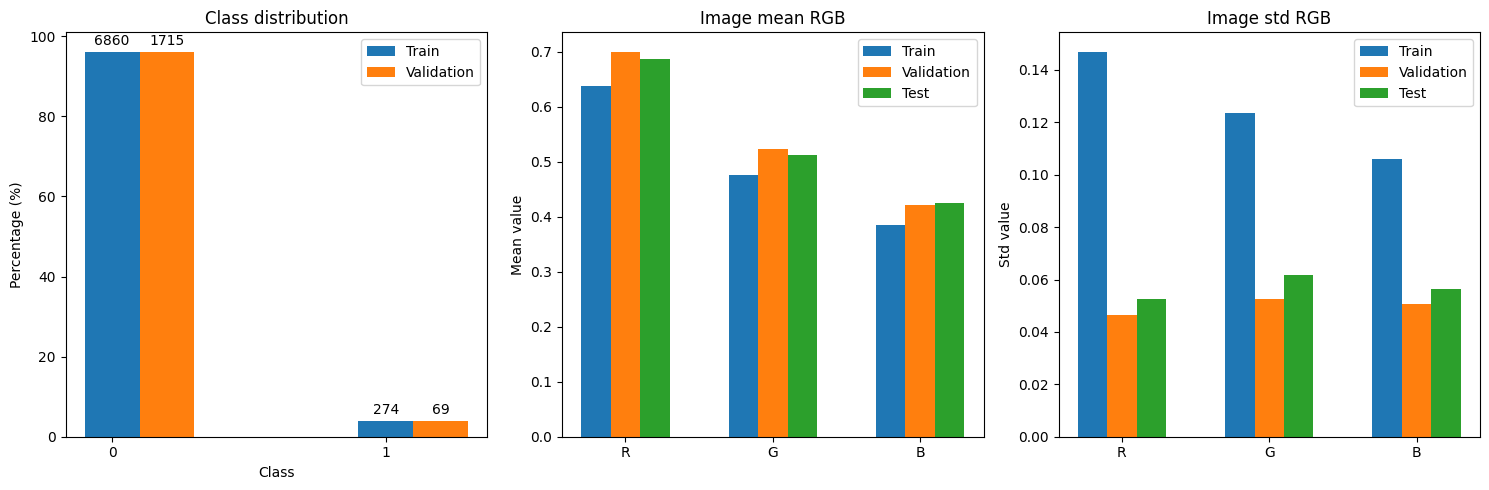

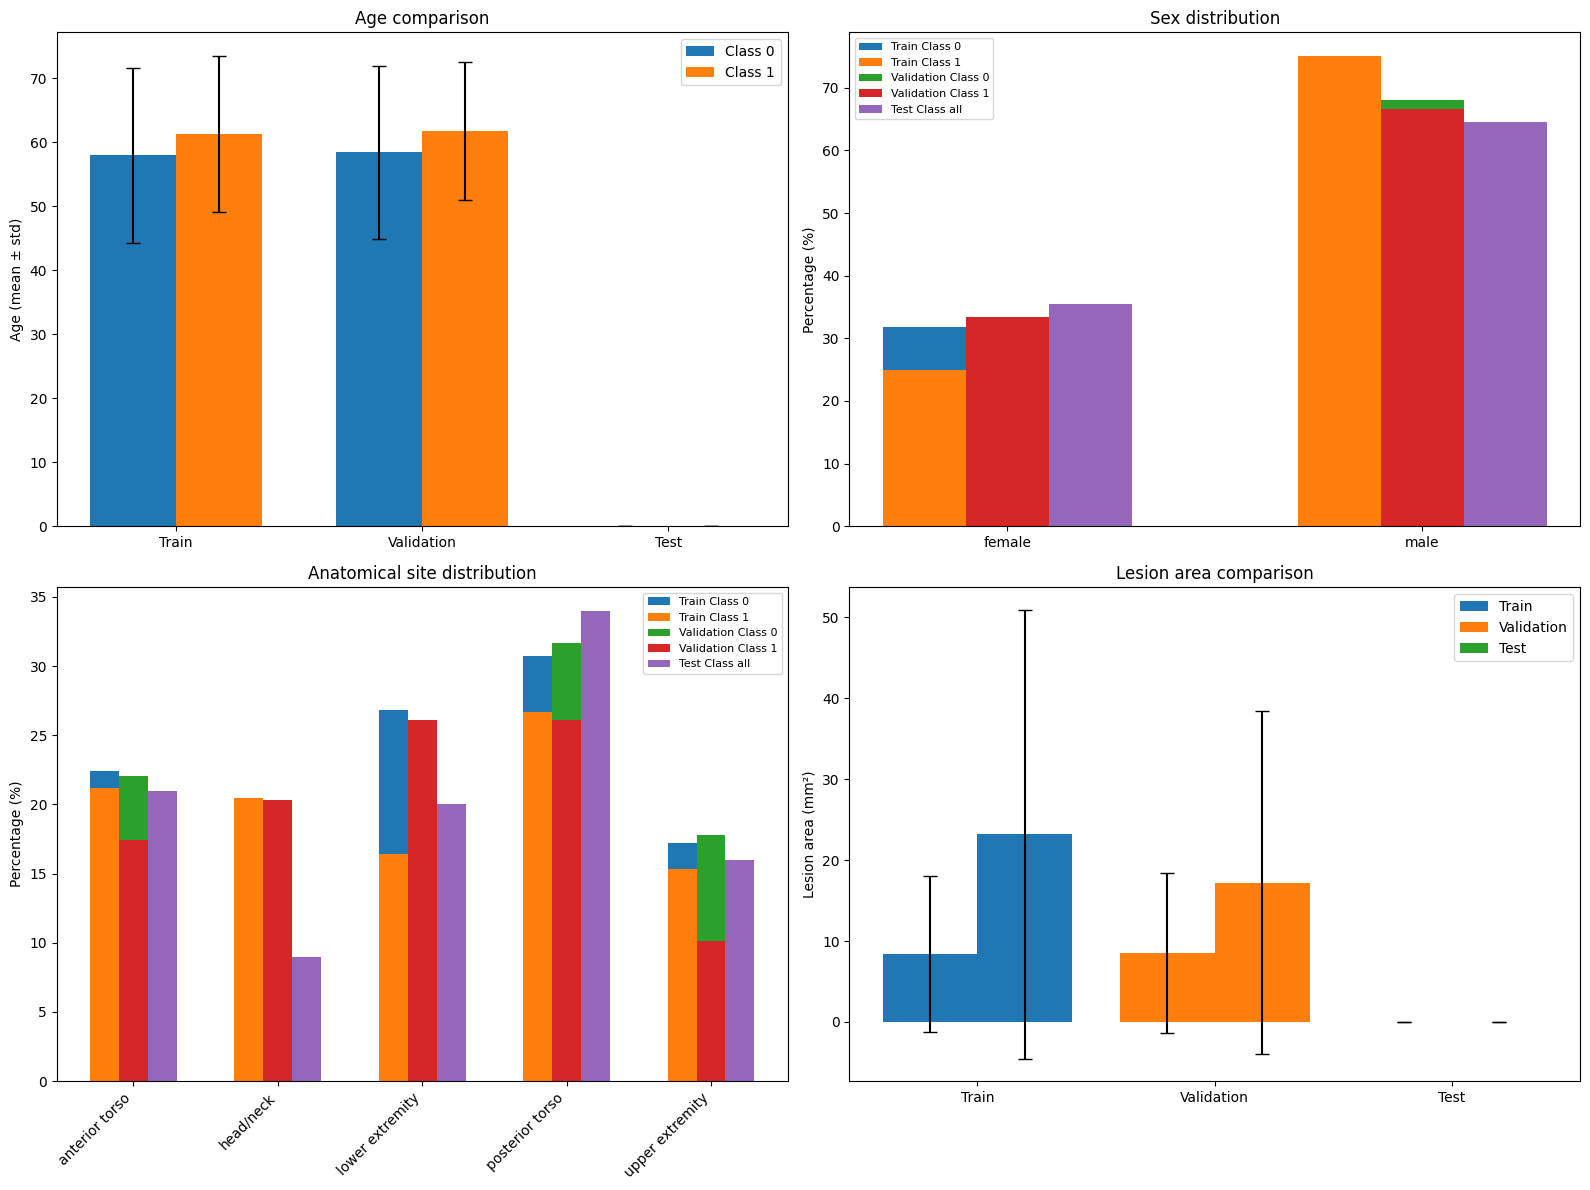

In [4]:
train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# clean dataset variables
train_dataset = None
val_dataset = None

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders with KFolds and Weighted sampler

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [5]:
kfold = StratifiedGroupKFold(
    n_splits=config.num_folds,
    shuffle=True,
    random_state=config.seed
)

# loaders 
traink_df = []
valk_df = []

fold_stats = []

for k, (train_idx, val_idx) in enumerate(
    kfold.split(train_df, train_df["target"], train_df["patient_id"])):

    train_spl = train_df.iloc[train_idx]
    val_spl = train_df.iloc[val_idx]

    train_counts = train_spl["target"].value_counts().reindex([0,1], fill_value=0)
    val_counts   = val_spl["target"].value_counts().reindex([0,1], fill_value=0)

    fold_stats.append({
        "fold": k,
        "train_total": len(train_spl),
        "tr_class_0": train_counts[0],
        "tr_class_1": train_counts[1],
        "tr_class1_%": train_counts[1] / len(train_spl),

        "val_total": len(val_spl),
        "val_class_0": val_counts[0],
        "val_class_1": val_counts[1],
        "val_class1_%": val_counts[1] / len(val_spl),
    })

    traink_df.append(train_spl)
    valk_df.append(val_spl)

# we only need test loader for kaggle submission
test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")
fold_stats_df = pd.DataFrame(fold_stats)

print("\n📊 Distribution for each fold:\n")
print(fold_stats_df.to_string(index=False))


📦 Multimodal data loaders created with balanced sampling!

📊 Distribution for each fold:

 fold  train_total  tr_class_0  tr_class_1  tr_class1_%  val_total  val_class_0  val_class_1  val_class1_%
    0         5697        5471         226     0.039670       1437         1389           48      0.033403
    1         5702        5474         228     0.039986       1432         1386           46      0.032123
    2         5837        5625         212     0.036320       1297         1235           62      0.047803
    3         5664        5447         217     0.038312       1470         1413           57      0.038776
    4         5636        5423         213     0.037793       1498         1437           61      0.040721


# Backbone

In [15]:
class AttentionFusion(nn.Module):
    """
    Fusiona img_emb y meta_emb usando Multi-Head Attention real.
    Produce una predicción escalar (1 dimensión).
    """
    def __init__(self, dim, num_heads=4, num_classes=1):
        super().__init__()

        # Multi-Head Attention (Transformer) para fusionar ambos tokens
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=False)

        # Proyección del token fusionado
        self.fusion_proj = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim // 2, dim // 4),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Predicción escalar final
        self.out = nn.Linear(dim // 4, num_classes)

    def forward(self, img_emb, meta_emb):
        """
        img_emb:  (batch, dim)
        meta_emb: (batch, dim)
        returns: (batch, 1)
        """

        # Construimos tokens → secuencia de longitud 2
        tokens = torch.stack([img_emb, meta_emb], dim=0)  
        # tokens shape: (2, batch, dim)

        # Self-attention sobre los dos tokens
        attn_out, _ = self.attn(tokens, tokens, tokens)
        # attn_out shape: (2, batch, dim)

        # Fusion: agregamos ambos tokens
        fused = attn_out.mean(dim=0)  # (batch, dim)

        # Pasamos por MLP
        fused = self.fusion_proj(fused)

        # Predicción escalar
        pred = self.out(fused)

        return pred
    
class EmbeddingHead(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(input_dim, emb_dim),
        nn.BatchNorm1d(emb_dim),
        nn.GELU()
        )
    
    def forward(self, x):
        return self.net(x)

class MetaEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.BatchNorm1d(hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim//2, emb_dim)
        )
    def forward(self, x):
        return self.net(x)

class PretrainedClassifier(nn.Module):
    def __init__(self, device, model_name, model_origin, meta_dim,
                 num_classes=1, hidden_dim = 512):
        super().__init__()

        self.hidden_dim = hidden_dim

        # ----- Backbone for the image ------
        if model_origin == ".pt":
            self.backbone = torch.load(model_name)
            # change last layer
            self.backbone = remove_last_layer(self.backbone)

        elif model_origin == "timm":
            self.backbone = timm.create_model(
                model_name,
                pretrained=True,
                global_pool='avg',
                num_classes=0  # don't use the original detection head
            )

        # add a trainable head to the backbone
        self.backbone.to(device)
        self.device = device
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224).to(device)
            img_feat = self.backbone(dummy_img)
        self.img_dim = img_feat.shape[1]

        # freeze the backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.backbone_head = EmbeddingHead(self.img_dim, 
                                          self.hidden_dim//2).to(device)
        
        # ------ Metadata Model -------
        self.metadata_encoder = MetaEncoder(meta_dim, emb_dim=self.hidden_dim//2).to(device)

        # ------ Fusion with attention ------
        self.attention_fusion = AttentionFusion(dim=self.hidden_dim//2, 
                                                num_heads=4,
                                                num_classes=num_classes
                                                ).to(device)


    def forward(self, images, metadata):
        # ---- Image embedding ----
        backbone_img = self.backbone(images)
        img_emb = self.backbone_head(backbone_img)

        # ---- Metadata embedding ---
        meta_emb = self.metadata_encoder(metadata)

        #----- Attention fusion -----
        out = self.attention_fusion(img_emb, meta_emb)
        return out
        
    def load(self, path):
        state = torch.load(path, map_location=self.device)
        self.load_state_dict(state)
        self.to(self.device)


class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, device, model_name, model_origin, unfreeze_scheduler, meta_dim,
                 lr, criterion, val_freq=5, patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, device, model_name, model_origin, meta_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name
        self.unfreeze_schedule = unfreeze_scheduler
        self.model_origin = model_origin
        self.val_freq = val_freq    # freq of validation metrics
        self.lr=lr
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            for e, pct in self.unfreeze_schedule:
                if epoch == e:
                    self.unfreeze_backbone_layers(pct)
                    print(f"Descongelando {pct*100:.0f}% del backbone en epoch {epoch}")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos:.3f}%")

            if val_loader and epoch%self.val_freq==0:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")
            
            # 🧹 Clean epoch for VRAM
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

            
            print(f" in {time.time() - start:.2f}s")

    def unfreeze_backbone_layers(self, percent=0.2):
        layers = list(self.backbone.parameters())
        n_total = len(layers)
        n_unfreeze = int(n_total * percent)

        # unfreeze the last layers
        for p in layers[-n_unfreeze:]:
            p.requires_grad = True

### Train the mix models

In [16]:
# Number of features coming from metadata
num_metadata_features = metadata_processor.transform(test_df).shape[1]

# -------------------------------------------------------------------------------
# 1º Define loss and model list
# -------------------------------------------------------------------------------
pos_weights = torch.tensor(config.BCE_loss_pos_weight).to(config.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# model names
# ["efficient_net_f0", "efficient_net_f1", "efficient_net_f2", "efficient_net_f3", "efficient_net_f4"]
model_paths = ["efficientnet_b0"] # "efficientnet_b1", "efficientnet_b2", "efficientnet_b3", "resnet18", "pvt_v2_b0" 
model_orig = ["timm", "timm", "timm", "timm", "timm", "timm"]
model_types = ["mix", "mix", "mix", "mix", "mix", "mix"]

model_list = [] # for ensemble

# -------------------------------------------------------------------------------
# 2º Train / load ensemble models
# -------------------------------------------------------------------------------
for i, (model_name, model_orig) in enumerate(zip(model_paths, model_orig)):

    # ------- Select the fold   ---------
    fold_idx = i % config.num_folds
    train_loader, val_loader = get_fold_datalodaers(
        train_df=traink_df[fold_idx],
        validation_df=valk_df[fold_idx], 
        train_hdf5=config.train_hdf5, 
        train_transform=train_transform,
        validation_transform=val_transform, 
        metadata_processor=metadata_processor, 
        c1_prop=config.target_epoch_proportion,                 
        num_img_epoch=config.num_imgs_epoch, 
        batch_size=config.fine_tuning_batch, 
        device=config.device)

    model_name_fold = f"{model_name}_f{fold_idx}"
    save_path = f"{config.models_dir}/{model_name_fold}.pt"

    if model_name_fold + ".pt" not in os.listdir(config.models_dir):
        print(f"\n⏳ Training {model_name_fold} ...")

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq)

        model.fit(train_loader, val_loader, epochs=config.fine_tuning_batch)
        model.save(save_path)

    else:

        model = PretrainedClassifier(
            device=config.device,
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features
        )
        model.load(save_path)
        print(f"📂 {model_name_fold} loaded from memory ({model.best_model_AUC:.4f})")
        labels, preds, probs = model.pred_probs(val_loader)
        plot_confusion_matrix(model_name, labels, preds)
        config.submission_dir.mkdir(parents=True, exist_ok=True)
        
        model.submit_kaggle(test_loader, 
                            submission_file=f"{config.submission_dir}/{model_name}.csv")

    model_list.append(model)


/tmp/ipykernel_41523/1460659342.py:141: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=self.device)


RuntimeError: Error(s) in loading state_dict for PretrainedClassifier:
	Unexpected key(s) in state_dict: "criterion.pos_weight". 

In [8]:
for i, m in enumerate(model_list):
    labels, preds, probs = m.pred_probs(val_loader)
    print(f"preds for {model_paths[i]}")
    print(f"labels num: {len(labels)}\t0:   {(labels==0).sum()}\t1: {(labels==1).sum()}")
    print(f"preds  num: {len(preds)}\t0:    {(preds==0).sum()}\t1: {(preds==1).sum()}")
    print(f"probs  num: {len(probs)},\t0.5>: {(probs>0.5).sum()}\tmin: {probs.min()}\tmax: {probs.max()}")

preds for efficientnet_b0
labels num: 1437	0:   1389	1: 48
preds  num: 1437	0:    1334	1: 103
probs  num: 1437,	0.5>: 103	min: 0.00021683535305783153	max: 0.9995132684707642


### Now we use the trained models in an ensemble to give more generalization power

In [9]:
class EnsembleClassifier(nn.Module):
    def __init__(self, models, models_type, metadata_dim, device, hidden_dim=64):
        super().__init__()

        # Freeze base models
        self.device = device
        self.metadata_dim = metadata_dim
        self.models = nn.ModuleList(models)
        self.num_models = len(models)
        for m in self.models:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        self.models_type = models_type

        # get the number and propierties of models
        output_dims = [
            self.get_output_dim(m, t, self.device) 
            for m, t in zip(self.models, self.models_type)
        ]

        self.meta_input_dim = sum(output_dims)

        # ------------ Meta-model ("stacker") ----------------
        self.meta_model = nn.Sequential(
            nn.Linear(self.meta_input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim//2, 1)
        )

    # ---------------------------------------------------------
    def forward(self, image, metadata):

        base_preds = []
        for m, mtype in zip(self.models, self.models_type):
            if mtype == "mix":
                preds = m(image, metadata)      # (batch, 1)
            elif mtype == "img":
                preds = m(image)
            elif mtype == "meta":
                preds = m(metadata)
            else:
                raise ValueError(f"Invalid type_input: {metadata}")
            
            if preds is None:
                raise RuntimeError("ERROR: A model returned None.")

            
            base_preds.append(preds)

        # concatenate the logits: shape → (batch, num_models)
        base_preds = torch.cat(base_preds, dim=1)

        # Process the model
        out = self.meta_model(base_preds)
        return out

    def get_output_dim(self, model, mtype, device):
        """Run a single dummy forward pass to infer output dimension."""
        
        model.eval()

        with torch.no_grad():
            if mtype == "img":
                dummy_img = torch.randn(1, 3, 224, 224).to(device)
                out = model(dummy_img)

            elif mtype == "meta":
                dummy_meta = torch.randn(1, self.metadata_dim).to(device)
                out = model(dummy_meta)

            elif mtype == "mix":
                dummy_img = torch.randn(1, 3, 224, 224).to(device)
                dummy_meta = torch.randn(1, self.metadata_dim).to(device)
                out = model(dummy_img, dummy_meta)

            else:
                raise ValueError("Invalid model type")
        
        return out.view(1, -1).shape[1]


class EnsembleClassifierExtended(EnsembleClassifier, TrainableModule):
    def __init__(self, models, models_type, criterion, device, metadata_dim,
                 patience=10, min_delta=0.01, num_epoc_val=5):
        EnsembleClassifier.__init__(self, models, models_type, metadata_dim, device)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.val_epoc = num_epoc_val
        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": [],
            "ensembles_val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            start = time.time()
            print(f"\nEpoch {epoch}/{epochs}: ", end="")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos}%")


            if val_loader and epoch%self.val_epoc==0:
                val_loss, val_auc, ensemble_aucs = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                self.history["ensembles_val_auc"].append(ensemble_aucs)
                print(f"\tVal Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")

    def _validate(self, loader):
        self.eval()
        total_loss = 0
        preds_list = []
        labels_list = []
        model_aucs = []

        with torch.no_grad():
            # calculate each model in ensemble roc auc
            for model, m_type in zip(self.models, self.models_type):
                model.eval()
                preds_model = []
                labels_model = []
                for images, metadata, labels, _ in loader:
                    images = images.to(self.device, non_blocking=True)
                    metadata = metadata.to(self.device, non_blocking=True)
                    labels = labels.float().to(self.device, non_blocking=True)

                    with amp.autocast(device_type=self.device.type):  # AMP
                        logits = self.forward_single(model, m_type, images, metadata)
                        probs = torch.sigmoid(logits)              # (B, K)
                        probs = probs.mean(dim=1)                  # (B,)  ← una predicción por imagen

                        preds_model.extend(probs.cpu().numpy().tolist())
                        labels_model.extend(labels.cpu().numpy().tolist())

                preds_model = np.array(preds_model)
                labels_model = np.array(labels_model)
                auc = roc_auc_score(labels_model, preds_model)
                model_aucs.append(auc)
            
            # calculate the combined roc auc
            for images, metadata, labels, _ in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)
                labels = labels.float().to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP
                    preds = self(images, metadata).squeeze()
                    loss = self.criterion(preds, labels)
                total_loss += loss.item()

                preds_list.append(preds.cpu())
                labels_list.append(labels.cpu())

        # update ensemble weights
        self.weights_ens = [a / sum(model_aucs) for a in model_aucs]

        preds = torch.cat(preds_list).sigmoid().numpy()
        labels = torch.cat(labels_list).numpy()
        auc_ensemble = roc_auc_score(labels, preds)

        return total_loss / len(loader), auc_ensemble, model_aucs
    
    def forward_single(self, model, mtype, images, metadata):
        if mtype == "img":
            return model(images)
        elif mtype == "meta":
            return model(metadata)
        elif mtype == "mix":
            return model(images, metadata)
        else:
            raise ValueError(f"Invalid model type: {mtype}")

    # -------------------------------------------------------------
    @classmethod
    def load(cls, path, model_name, metadata_dim, criterion, device):
        model = cls(model_name, metadata_dim, criterion, device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model


### Voting ensemble

In [10]:
class VoteEnsembleClassifier(nn.Module):
    def __init__(self, models, models_type, models_names, metadata_dim, device, weights=None):
        super().__init__()

        self.device = device
        self.models = nn.ModuleList(models)
        self.models_type = models_type
        self.metadata_dim = metadata_dim
        self.num_models = len(models)
        self.model_names = models_names

        # Freeze base models
        for m in self.models:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        # Voting weights (normalized)
        if weights is None:
            self.weights = torch.ones(self.num_models) / self.num_models
        else:
            w = torch.tensor(weights, dtype=torch.float32)
            self.weights = w / w.sum()

        self.weights = self.weights.to(device)

    # -------------------------------------------------------
    def forward(self, image, metadata):

        preds = []

        for m, mtype in zip(self.models, self.models_type):

            if mtype == "img":
                logit = m(image)

            elif mtype == "meta":
                logit = m(metadata)

            elif mtype == "mix":
                logit = m(image, metadata)

            else:
                raise ValueError(f"Invalid model type: {mtype}")

            if logit is None:
                raise RuntimeError("A model returned None.")
            preds.append(torch.sigmoid(logit))   # convertir a prob

        # stack preds → (B, num_models)
        preds = torch.cat(preds, dim=1)

        # Weighted average
        final = (preds * self.weights).sum(dim=1, keepdim=True)

        return final
    
class VoteEnsembleClassifierExtended(VoteEnsembleClassifier, TrainableModule):
    def __init__(self, models, models_type, models_names, criterion, device,
                 metadata_dim, weights=None,
                 patience=10, min_delta=0.01, num_epoc_val=5):

        VoteEnsembleClassifier.__init__(
            self, models, models_type, models_names, metadata_dim, device, weights
        )
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.val_epoc = num_epoc_val

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": [],
            "ensembles_val_auc": []
        }

    # ----------------------------------------------
    def fit(self, train_loader, val_loader=None, epochs=10):

        for epoch in range(1, epochs+1):

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Epoch {epoch}/{epochs} train_loss={train_loss:.4f}")

            if val_loader and epoch % self.val_epoc == 0:

                val_loss, val_auc, model_aucs = self._validate(val_loader)

                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                self.history["ensembles_val_auc"].append(model_aucs)

                # update weights by normalized auc
                auc_tensor = torch.tensor(model_aucs).float().to(self.device)
                self.weights = auc_tensor / auc_tensor.sum()
                self.print_weights()

                print(f"  ▸ Val Loss={val_loss:.4f} | AUC={val_auc:.4f}")
                
    def _train_epoch(self, loader):
        self.train()
        total_loss = 0

        with torch.no_grad():  # no grad porque no entrenamos nada
            for images, metadata, labels, _ in loader:
                images = images.to(self.device)
                metadata = metadata.to(self.device)
                labels = labels.float().to(self.device)

                preds = self(images, metadata).view(-1)
                loss = self.criterion(preds, labels)

                total_loss += loss.item()

        return total_loss / len(loader), None

    # ----------------------------------------------
    def _validate(self, loader):
        self.eval()
        total_loss = 0
        preds_list, labels_list = [], []
        model_aucs = []

        with torch.no_grad():

            # AUC por modelo individual
            for model, mtype in zip(self.models, self.models_type):
                pred_m, lab_m = [], []
                for images, metadata, labels, _ in loader:
                    images = images.to(self.device)
                    metadata = metadata.to(self.device)
                    labels = labels.float().to(self.device)

                    logits = self.forward_single(model, mtype, images, metadata)
                    probs = torch.sigmoid(logits).squeeze()

                    pred_m.extend(probs.cpu().numpy().tolist())
                    lab_m.extend(labels.cpu().numpy().tolist())

                auc = roc_auc_score(lab_m, pred_m)
                model_aucs.append(auc)

            # AUC del ensemble
            for images, metadata, labels, _ in loader:
                images = images.to(self.device)
                metadata = metadata.to(self.device)
                labels = labels.float().to(self.device)

                preds = self(images, metadata).squeeze()
                loss = self.criterion(preds, labels)
                total_loss += loss.item()

                preds_list.append(preds.cpu())
                labels_list.append(labels.cpu())

        preds = torch.cat(preds_list).numpy()
        labels = torch.cat(labels_list).numpy()
        auc_ensemble = roc_auc_score(labels, preds)

        # save the best model
        if auc > self.best_model_AUC:
            self.best_model_AUC = auc
            self.best_model = {k: v.cpu() for k, v in self.state_dict().items()}
            

        return total_loss / len(loader), auc_ensemble, model_aucs

    # ---------------------------------------------------------
    def forward_single(self, model, mtype, images, metadata):
        if mtype == "img":
            return model(images)
        elif mtype == "meta":
            return model(metadata)
        elif mtype == "mix":
            return model(images, metadata)
        else:
            raise ValueError("Invalid model type")
        
    # ---------------------------------------------------------
    def print_weights(self):
        print("\n  ▸ Ensemble Weights:")
        for name, w in zip(self.model_names, self.weights):
            print(f"      {name}: {float(w)*100:.1f}%")



# Train Ensemble


efficientnet_b4,
efficientnet_b0,
resnet18,
resnet50,
vgg13,
vgg16,
vit_tiny_patch16_224.augreg_in21k_ft_in1k

In [11]:
#-------------------------------------------------------------------------------
# 2º Train ensemble
#-------------------------------------------------------------------------------
ensemble_name = "ensemble"
save_path = f"{config.models_dir}/{ensemble_name}.pt"
if ensemble_name+".pth" not in os.listdir(config.models_dir):
    print("\n-------- FITTING ENSEMBLE ----------\n")
    ensemble_class = VoteEnsembleClassifierExtended(
                        models=model_list,
                        models_type=model_types,
                        models_names=model_paths,
                        metadata_dim=num_metadata_features,
                        criterion=criterion,
                        device=config.device,
                        patience=config.epochs, 
                        num_epoc_val=config.val_freq
                    )

    # get the first fold
    train_loader, val_loader = get_fold_datalodaers(
        train_df=traink_df[0],
        validation_df=valk_df[0], 
        train_hdf5=config.train_hdf5, 
        train_transform=train_transform,
        validation_transform=val_transform, 
        metadata_processor=metadata_processor, 
        c1_prop=config.target_epoch_proportion,                 
        num_img_epoch=config.num_imgs_epoch, 
        batch_size=config.fine_tuning_batch, 
        device=config.device)
    
    ensemble_class.fit(train_loader, val_loader, epochs=config.epochs)

    ensemble_class.save(save_path)
else:
    print(f"📂 {ensemble_name} loaded from memory")
    ensemble_class = VoteEnsembleClassifierExtended(
                        models=model_list,
                        models_type=model_types,
                        models_names=model_paths,
                        metadata_dim=num_metadata_features,
                        criterion=criterion,
                        device=config.device,
                        patience=config.epochs, 
                        num_epoc_val=config.val_freq
                    )
    model.load(save_path)
    config.submission_dir.mkdir(parents=True, exist_ok=True)
        
    model.submit_kaggle(test_loader, 
                        submission_file=f"{config.submission_dir}/{model_name}.csv")


-------- FITTING ENSEMBLE ----------



KeyboardInterrupt: 

In [ ]:
#-------------------------------------------------------------------------------
# 2º Train ensemble
#-------------------------------------------------------------------------------
ensemble_name = "ensemble"
save_path = f"{config.models_dir}/{ensemble_name}.pt"
if ensemble_name+".pth" not in os.listdir(config.models_dir):
    print("\n-------- FITTING ENSEMBLE ----------\n")
    ensemble_class = EnsembleClassifierExtended(
                        models=model_list,
                        models_type=model_types,
                        metadata_dim=num_metadata_features,
                        criterion=criterion,
                        device=config.device,
                        patience=config.epochs, 
                        num_epoc_val=config.val_freq)

    # get the first fold
    train_loader, val_loader = get_fold_datalodaers(
        train_df=traink_df[0],
        validation_df=valk_df[0], 
        train_hdf5=config.train_hdf5, 
        train_transform=train_transform,
        validation_transform=val_transform, 
        metadata_processor=metadata_processor, 
        c1_prop=config.target_epoch_proportion,                 
        num_img_epoch=config.num_imgs_epoch, 
        batch_size=config.fine_tuning_batch, 
        device=config.device)
    
    ensemble_class.fit(train_loader, val_loader, epochs=config.epochs)

    ensemble_class.save(save_path)
else:
    print(f"📂 {ensemble_name} loaded from memory")
    ensemble_class = EnsembleClassifierExtended(
                        models=model_list,
                        models_type=model_types,
                        metadata_dim=num_metadata_features,
                        criterion=criterion,
                        device=config.device,
                        patience=config.epochs, 
                        num_epoc_val=config.val_freq)
    model.load(save_path)
    config.submission_dir.mkdir(parents=True, exist_ok=True)
        
    model.submit_kaggle(test_loader, 
                        submission_file=f"{config.submission_dir}/{model_name}.csv")


-------- FITTING ENSEMBLE ----------


Epoch 1/50: 

Train loss: 0.6932 || percentaje pos in epoch: 0.5096666666666667%
 in 24.22s

Epoch 2/50: 

Train loss: 0.6932 || percentaje pos in epoch: 0.4846666666666667%
 in 25.12s

Epoch 3/50: 

Train loss: 0.6931 || percentaje pos in epoch: 0.4766666666666667%
 in 24.91s

Epoch 4/50: 

Train loss: 0.6931 || percentaje pos in epoch: 0.5023333333333333%
 in 25.04s

Epoch 5/50: 

...

Train loss: 0.6932 || percentaje pos in epoch: 0.5176666666666667%
 in 25.22s

Epoch 15/50: 

Train loss: 0.6931 || percentaje pos in epoch: 0.47733333333333333%


	Val Loss: 0.6913 | AUC: 0.5000 in 46.26s

Epoch 16/50: 

Train loss: 0.6932 || percentaje pos in epoch: 0.49933333333333335%
 in 25.54s

Epoch 17/50: 

KeyboardInterrupt: 

### Plot the results of the train

In [ ]:
# conffusion matrix of all models and the ensemble
n_models = len(model_list)
total_plots = n_models + 1  # including ensemble

fig, axes = plt.subplots(1, total_plots, figsize=(5*total_plots, 5))

# Plot individual models
for i, model in enumerate(model_list):
    labels, preds, _ = model.pred_probs(val_loader)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d')
    axes[i].set_title(model_paths[i])

# Plot ensemble
labels, preds, _ = ensemble_class.pred_probs(val_loader)
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(ax=axes[-1], cmap=plt.cm.Blues, values_format='d')
axes[-1].set_title("Ensemble")

plt.tight_layout()
plt.show()

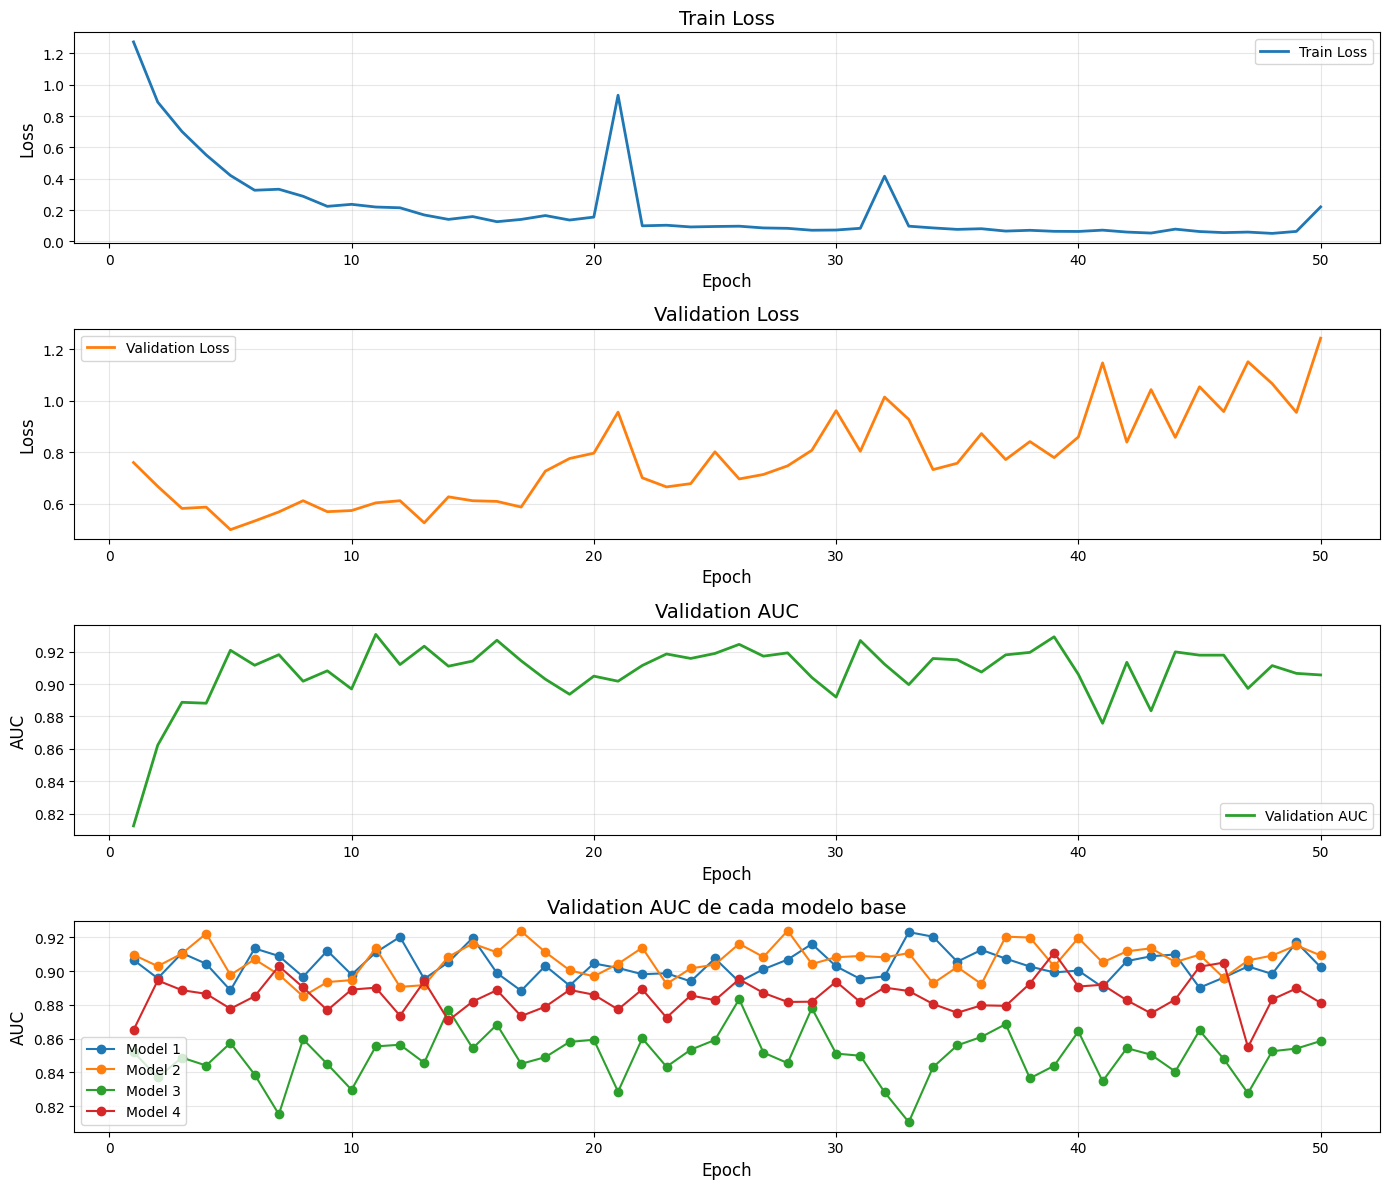

In [ ]:
train_loss = ensemble_class.history["train_loss"]
val_loss = ensemble_class.history["val_loss"]
val_auc = ensemble_class.history["val_auc"]
ensemble_model_aucs = ensemble_class.history.get("ensembles_val_auc", [])

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14, 12))

# 1. TRAIN LOSS
plt.subplot(4, 1, 1)
plt.plot(epochs, train_loss, label="Train Loss", color="tab:blue", linewidth=2)
plt.title("Train Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 2. VALIDATION LOSS
plt.subplot(4, 1, 2)
plt.plot(epochs, val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
plt.title("Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 3. VALIDATION AUC
plt.subplot(4, 1, 3)
plt.plot(epochs, val_auc, label="Validation AUC", color="tab:green", linewidth=2)
plt.title("Validation AUC", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 4)
if ensemble_model_aucs:
    ensemble_model_aucs = np.array(ensemble_model_aucs)  # shape [epochs, n_models]
    n_models = ensemble_model_aucs.shape[1]
    for i in range(n_models):
        plt.plot(epochs, ensemble_model_aucs[:, i], marker='o', label=f'Model {i+1}')
    plt.title("Validation AUC de cada modelo base", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("AUC", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()